In [6]:
from google.colab import files

uploaded = files.upload()

Saving time_series_60min_singleindex.csv to time_series_60min_singleindex.csv


In [7]:
import pandas as pd

df = pd.read_csv(
    "time_series_60min_singleindex.csv",
    parse_dates=['utc_timestamp']
)

print(df.shape)
print(df.columns[:20])

(50401, 300)
Index(['utc_timestamp', 'cet_cest_timestamp',
       'AT_load_actual_entsoe_transparency',
       'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead',
       'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual',
       'BE_load_actual_entsoe_transparency',
       'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual',
       'BE_wind_generation_actual', 'BE_wind_offshore_generation_actual',
       'BE_wind_onshore_generation_actual',
       'BG_load_actual_entsoe_transparency',
       'BG_load_forecast_entsoe_transparency', 'BG_solar_generation_actual',
       'BG_wind_onshore_generation_actual',
       'CH_load_actual_entsoe_transparency',
       'CH_load_forecast_entsoe_transparency', 'CH_solar_capacity'],
      dtype='object')


In [8]:
df['load'] = (
    df['DE_amprion_load_actual_entsoe_transparency'].fillna(0)
    + df['DE_tennet_load_actual_entsoe_transparency'].fillna(0)
    + df['DE_transnetbw_load_actual_entsoe_transparency'].fillna(0)
)

In [9]:
energy = pd.DataFrame({
    'price': df['DE_LU_price_day_ahead'],
    'load': df['load'],
    'wind': df['DE_LU_wind_generation_actual'],
    'solar': df['DE_LU_solar_generation_actual']
})

energy.index = df['utc_timestamp']

print(energy.shape)
energy.head()

(50401, 4)


,price,load,wind,solar
utc_timestamp,,,,
2014-12-31 23:00:00+00:00,NaN,0.0,NaN,NaN
2015-01-01 00:00:00+00:00,NaN,34311.0,NaN,NaN
2015-01-01 01:00:00+00:00,NaN,33180.0,NaN,NaN
2015-01-01 02:00:00+00:00,NaN,32013.0,NaN,NaN
2015-01-01 03:00:00+00:00,NaN,31400.0,NaN,NaN


In [10]:
energy = energy.dropna()

print(energy.shape)
print(energy.isna().sum())
print(energy.head())
print(energy.tail())

(17534, 4)
price    0
load     0
wind     0
solar    0
dtype: int64
                           price     load     wind    solar
utc_timestamp                                              
2018-10-01 05:00:00+00:00  77.32  50370.0  10491.0    208.0
2018-10-01 06:00:00+00:00  84.97  52844.0  10705.0   2008.0
2018-10-01 07:00:00+00:00  79.56  53412.0  10201.0   5132.0
2018-10-01 08:00:00+00:00  73.70  54296.0  10670.0   8344.0
2018-10-01 09:00:00+00:00  71.63  55552.0  12937.0  10209.0
                           price     load     wind  solar
utc_timestamp                                            
2020-09-30 18:00:00+00:00  55.34  49428.0   8526.0    0.0
2020-09-30 19:00:00+00:00  49.92  46407.0  10654.0    0.0
2020-09-30 20:00:00+00:00  42.79  43546.0  11836.0    0.0
2020-09-30 21:00:00+00:00  35.02  40009.0  12168.0    0.0
2020-09-30 22:00:00+00:00  34.40  37725.0  12533.0    0.0


In [11]:
energy.to_csv('energy_master.csv')

In [12]:
#battery characteristics
battery = {
    'capacity': 100,      # MWh
    'charge_rate': 25,    # MW/h
    'discharge_rate': 25, # MW/h
    'efficiency': 0.90
}

battery

{'capacity': 100, 'charge_rate': 25, 'discharge_rate': 25, 'efficiency': 0.9}

In [13]:
battery_df = energy[['price']].copy()

battery_df['ma24'] = battery_df['price'].rolling(24).mean()

battery_df['soc'] = 0.0
battery_df['action'] = 'hold'
battery_df['profit'] = 0.0
battery_df['cum_profit'] = 0.0

battery_df.dropna(inplace=True)

battery_df.head()

,price,ma24,soc,action,profit,cum_profit
utc_timestamp,,,,,,
2018-10-02 04:00:00+00:00,57.70,58.927917,0.0,hold,0.0,0.0
2018-10-02 05:00:00+00:00,68.21,58.548333,0.0,hold,0.0,0.0
2018-10-02 06:00:00+00:00,70.36,57.939583,0.0,hold,0.0,0.0
2018-10-02 07:00:00+00:00,54.53,56.896667,0.0,hold,0.0,0.0
2018-10-02 08:00:00+00:00,48.49,55.846250,0.0,hold,0.0,0.0


In [14]:
soc = 0

for i in range(len(battery_df)):

    price = battery_df.iloc[i]['price']
    ma = battery_df.iloc[i]['ma24']

    if price < ma and soc < battery['capacity']:
        charge = min(
            battery['charge_rate'],
            battery['capacity'] - soc
        )

        soc += charge * battery['efficiency']

        battery_df.iloc[i,
                        battery_df.columns.get_loc('action')] = 'charge'

        battery_df.iloc[i,
                        battery_df.columns.get_loc('profit')] = -charge * price

    elif price > ma and soc > 0:

        discharge = min(
            battery['discharge_rate'],
            soc
        )

        soc -= discharge

        battery_df.iloc[i,
                        battery_df.columns.get_loc('action')] = 'discharge'

        battery_df.iloc[i,
                        battery_df.columns.get_loc('profit')] = discharge * price

    battery_df.iloc[i,
                    battery_df.columns.get_loc('soc')] = soc

In [15]:
#calculation of results
battery_df['cum_profit'] = battery_df['profit'].cumsum()

print("Total profit:",
      battery_df['profit'].sum())

print()
print(battery_df['action'].value_counts())

Total profit: 772231.0631949594

action
charge       8907
hold         4798
discharge    3806
Name: count, dtype: int64


In [16]:
#performance analysis
#battery returns
battery_df['returns'] = battery_df['profit']

print(
    battery_df['returns'].describe()
)

count    17511.000000
mean        44.099769
std        677.514254
min      -1950.000000
25%       -161.951630
50%          0.000000
75%          0.000000
max       3264.750000
Name: returns, dtype: float64


In [19]:
import numpy as np
#Sharpe Ratio
#Τι επιδιώκουμε; Να δούμε αν τα κέρδη είναι σταθερά ή προέρχονται από λίγες καλές συναλλαγές.
sharpe = (
    battery_df['returns'].mean()
    /
    battery_df['returns'].std()
) * np.sqrt(24*365)

print("Battery Sharpe:", sharpe)

Battery Sharpe: 6.092140847010097


In [20]:
#Maximum Drawdown
#Τι επιδιώκουμε;Να δούμε ποια ήταν η χειρότερη περίοδος απωλειών
equity = battery_df['cum_profit']

running_max = equity.cummax()

drawdown = equity - running_max

max_dd = drawdown.min()

print("Maximum Drawdown:", max_dd)

Maximum Drawdown: -8749.713754997676


In [21]:
#battery cycles
cycles = (
    battery_df['action']
    .eq('discharge')
    .sum()
)

print("Battery cycles:", cycles)

Battery cycles: 3806


In [22]:
#utilization
utilization = (
    battery_df['soc'].mean()
    /
    battery['capacity']
)

print(
    "Average utilization:",
    utilization
)

Average utilization: 0.5036425305302675


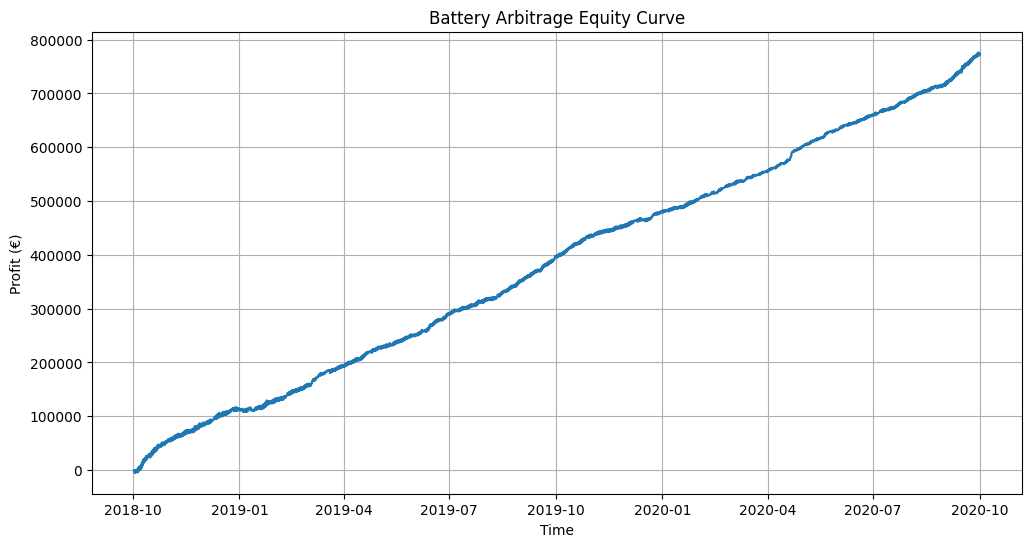

In [23]:
#equity curve
#Να δούμε αν η στρατηγική παράγει ομαλή αύξηση κερδών
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(battery_df['cum_profit'])
plt.title('Battery Arbitrage Equity Curve')
plt.xlabel('Time')
plt.ylabel('Profit (€)')
plt.grid(True)
plt.show()

Η πρώτη στρατηγική ήταν:

charge:
    price < MA24

discharge:
    price > MA24
  this strategy provides great results but we want to improve it

In [24]:
#ptimization battery parameters.
capacities = [50,100,200]
rates = [10,25,50]
efficiencies = [0.85,0.90,0.95]
lookbacks = [12,24,48,72]

results = []

In [25]:
#creation a list of results
import numpy as np
import pandas as pd

results = []

for capacity in capacities:

    for rate in rates:

        for eff in efficiencies:

            for lookback in lookbacks:

                temp = energy[['price']].copy()

                temp['ma'] = (
                    temp['price']
                    .rolling(lookback)
                    .mean()
                )

                temp = temp.dropna()

                soc = 0
                profits = []

                for _, row in temp.iterrows():

                    price = row['price']
                    ma = row['ma']

                    profit = 0

                    if price < ma and soc < capacity:

                        charge = min(
                            rate,
                            capacity - soc
                        )

                        soc += charge * eff

                        profit = -charge * price

                    elif price > ma and soc > 0:

                        discharge = min(
                            rate,
                            soc
                        )

                        soc -= discharge

                        profit = discharge * price

                    profits.append(profit)

                profits = np.array(profits)

                equity = profits.cumsum()

                if profits.std() > 0:
                    sharpe = (
                        profits.mean()
                        /
                        profits.std()
                    ) * np.sqrt(24*365)
                else:
                    sharpe = np.nan

                running_max = np.maximum.accumulate(equity)
                drawdown = equity - running_max

                results.append([
                    capacity,
                    rate,
                    eff,
                    lookback,
                    profits.sum(),
                    sharpe,
                    drawdown.min()
                ])

Για κάθε συνδυασμό:

capacity
charge/discharge rate
efficiency
moving average lookback

υπολογίζει:

συνολικό profit,
Sharpe ratio,
maximum drawdown.

Συνολικά θα δοκιμαστούν:

3 × 3 × 3 × 4 = 108 διαφορετικές μπαταρίες

In [26]:
#create dataframe
results = pd.DataFrame(
    results,
    columns=[
        'capacity',
        'rate',
        'efficiency',
        'lookback',
        'profit',
        'sharpe',
        'drawdown'
    ]
)

results.sort_values(
    'profit',
    ascending=False
).head(10)

,capacity,rate,efficiency,lookback,profit,sharpe,drawdown
105,200,50,0.95,24,1.886610e+06,7.446541,-14891.987406
106,200,50,0.95,48,1.713491e+06,7.222060,-15106.205249
104,200,50,0.95,12,1.688054e+06,6.235411,-17468.831897
107,200,50,0.95,72,1.593700e+06,7.051462,-14483.104979
101,200,50,0.90,24,1.544462e+06,6.092315,-17499.427510
93,200,25,0.95,24,1.467013e+06,9.757752,-13175.712000
92,200,25,0.95,12,1.458337e+06,8.936923,-15153.527000
102,200,50,0.90,48,1.413091e+06,5.949895,-15907.206102
103,200,50,0.90,72,1.320548e+06,5.837160,-15286.619432
100,200,50,0.90,12,1.289605e+06,4.759418,-27576.352919


In [28]:
#Degradation cost
degradation_cost = 5

capacity = 200
rate = 50
eff = 0.95
lookback = 24

temp = energy[['price']].copy()
temp['ma'] = temp['price'].rolling(lookback).mean()
temp = temp.dropna()

soc = 0
profits = []
cycles = 0

for _, row in temp.iterrows():

    price = row['price']
    ma = row['ma']

    profit = 0

    if price < ma and soc < capacity:

        charge = min(rate, capacity - soc)

        soc += charge * eff

        profit = -charge * price - charge * degradation_cost

    elif price > ma and soc > 0:

        discharge = min(rate, soc)

        soc -= discharge

        profit = (
            discharge * price
            - discharge * degradation_cost
        )

        cycles += 1

    profits.append(profit)

profits = np.array(profits)

print("Profit:", profits.sum())
print("Cycles:", cycles)

Profit: -54538.37146681594
Cycles: 3806


Εξακολουθεί να είναι κερδοφόρα η μπαταρία όταν λάβουμε υπόψη τη φθορά της;
Naive battery arbitrage
Profit:
+1.89M €
Realistic battery arbitrage
Profit:
-54k €

In [29]:
#Threshold Battery Arbitrage
temp = energy[['price']].copy()

temp['ma'] = temp['price'].rolling(24).mean()
temp['std'] = temp['price'].rolling(24).std()

temp = temp.dropna()

temp.head()

,price,ma,std
utc_timestamp,,,
2018-10-02 04:00:00+00:00,57.70,58.927917,13.170004
2018-10-02 05:00:00+00:00,68.21,58.548333,12.741165
2018-10-02 06:00:00+00:00,70.36,57.939583,11.733036
2018-10-02 07:00:00+00:00,54.53,56.896667,10.803288
2018-10-02 08:00:00+00:00,48.49,55.846250,10.312914


In [30]:
#Threshold battery strategy
k = 1

capacity = 200
rate = 50
eff = 0.95
degradation = 5

soc = 0
profits = []
actions = []

for _, row in temp.iterrows():

    price = row['price']
    ma = row['ma']
    sigma = row['std']

    lower = ma - k*sigma
    upper = ma + k*sigma

    profit = 0
    action = 'hold'

    if price < lower and soc < capacity:

        charge = min(rate, capacity-soc)

        soc += charge*eff

        profit = -charge*price - charge*degradation

        action = 'charge'

    elif price > upper and soc > 0:

        discharge = min(rate, soc)

        soc -= discharge

        profit = discharge*price - discharge*degradation

        action = 'discharge'

    profits.append(profit)
    actions.append(action)

In [31]:
#results
profits = np.array(profits)

equity = profits.cumsum()

sharpe = (
    profits.mean()
    /
    profits.std()
) * np.sqrt(24*365)

running_max = np.maximum.accumulate(equity)
drawdown = equity-running_max

print("Profit:", profits.sum())
print("Sharpe:", sharpe)
print("Max DD:", drawdown.min())
print()
print(pd.Series(actions).value_counts())

Profit: 499226.78388607595
Sharpe: 3.193641816030945
Max DD: -17624.72703806284

hold         12633
charge        3353
discharge     1525
Name: count, dtype: int64


In [32]:
#let's find the best threshold
ks = [0.5,1,1.5,2]

threshold_results = []

for k in ks:

    soc = 0
    profits = []
    cycles = 0

    for _, row in temp.iterrows():

        price = row['price']
        ma = row['ma']
        sigma = row['std']

        lower = ma - k*sigma
        upper = ma + k*sigma

        profit = 0

        if price < lower and soc < capacity:

            charge = min(rate, capacity-soc)

            soc += charge*eff

            profit = (
                -charge*price
                -charge*degradation
            )

        elif price > upper and soc > 0:

            discharge = min(rate, soc)

            soc -= discharge

            profit = (
                discharge*price
                -discharge*degradation
            )

            cycles += 1

        profits.append(profit)

    profits = np.array(profits)

    sharpe = (
        profits.mean()/profits.std()
    ) * np.sqrt(24*365)

    threshold_results.append([
        k,
        profits.sum(),
        sharpe,
        cycles
    ])

threshold_results = pd.DataFrame(
    threshold_results,
    columns=[
        'k',
        'profit',
        'sharpe',
        'cycles'
    ]
)

print(threshold_results)

     k         profit    sharpe  cycles
0  0.5  463594.406793  2.199018    2697
1  1.0  499226.783886  3.193642    1525
2  1.5  390532.964136  4.155343     613
3  2.0  414108.021040  6.832287     261


k = 0.5
πολλά trades
πολύ degradation
μικρότερο Sharpe

Η στρατηγική είναι υπερβολικά επιθετική.

k = 1
Profit = 499k €
Sharpe = 3.19
Cycles = 1525

Αυτό φαίνεται να είναι το profit optimum.

k = 1.5

Εδώ αρχίζουμε να χάνουμε opportunities, αλλά αποκτούμε μεγαλύτερη σταθερότητα.

k = 2
Profit = 414k €
Sharpe = 6.83
Cycles = 261

Αυτό είναι εξαιρετικά ενδιαφέρον.

Η στρατηγική:

κάνει ελάχιστους κύκλους,
έχει πολύ υψηλό risk-adjusted return,
πιθανότατα είναι η πιο ρεαλιστική για πραγματική εφαρμογή.